In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
import sklearn
import matplotlib
import seaborn

print("Library versions")
print("-" * 50)
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {seaborn.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")


Library versions
--------------------------------------------------
NumPy version: 2.0.2
Pandas version: 2.3.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1


In [3]:
file_path = "/kaggle/input/datasets/sneharakshit511/diabetes/diabetes_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Number of rows: 768
Number of columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [4]:
expected_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

actual_columns = df.columns.tolist()

missing_columns = [
    column
    for column in expected_columns
    if column not in actual_columns
]

unexpected_columns = [
    column
    for column in actual_columns
    if column not in expected_columns
]

print("Dataset validation results")
print("-" * 50)

if len(missing_columns) > 0:
    print(f"Missing required columns: {missing_columns}")
    raise ValueError(
        "The dataset does not contain all required columns."
    )
else:
    print("All required columns are available.")

if len(unexpected_columns) > 0:
    print(f"Unexpected columns found: {unexpected_columns}")
else:
    print("No unexpected columns were found.")

print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")

Dataset validation results
--------------------------------------------------
All required columns are available.
No unexpected columns were found.
Total records: 768
Total columns: 9


In [5]:
if df["Outcome"].isnull().any():
    raise ValueError(
        "The Outcome column contains missing values."
    )

unique_outcomes = sorted(
    df["Outcome"].unique().tolist()
)

invalid_outcomes = [
    value
    for value in unique_outcomes
    if value not in [0, 1]
]

if len(invalid_outcomes) > 0:
    raise ValueError(
        f"Outcome contains invalid values: {invalid_outcomes}"
    )

print("Target variable validation completed.")
print(f"Unique Outcome values: {unique_outcomes}")
print("0 means No Diabetes.")
print("1 means Diabetes.")

Target variable validation completed.
Unique Outcome values: [0, 1]
0 means No Diabetes.
1 means Diabetes.


In [6]:
print("Dataset shape")
print("-" * 50)
print(df.shape)

print("\nColumn names")
print("-" * 50)

for position, column in enumerate(
    df.columns,
    start=1
):
    print(f"{position}. {column}")

Dataset shape
--------------------------------------------------
(768, 9)

Column names
--------------------------------------------------
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome


In [8]:
print("Data types")
print("-" * 50)

data_type_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(data_type_summary)

print("\nDetailed dataset information")
print("-" * 50)

df.info()

Data types
--------------------------------------------------


,Column,Data Type
0,Pregnancies,int64
1,Glucose,int64
2,BloodPressure,int64
3,SkinThickness,int64
4,Insulin,int64
5,BMI,float64
6,DiabetesPedigreeFunction,float64
7,Age,int64
8,Outcome,int64



Detailed dataset information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
missing_value_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    )
})

missing_value_summary = missing_value_summary.sort_values(
    by="Missing Count",
    ascending=False
)

print("Standard missing value summary")
display(missing_value_summary)

total_missing_values = int(
    df.isnull().sum().sum()
)

print(
    f"Total standard missing values: "
    f"{total_missing_values}"
)

Standard missing value summary


,Missing Count,Missing Percentage
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
SkinThickness,0,0.000
Insulin,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


Total standard missing values: 0


In [10]:
duplicate_count = int(
    df.duplicated().sum()
)

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(f"Duplicate records: {duplicate_count}")
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

if duplicate_count > 0:
    print("\nDuplicate records:")
    display(
        df[df.duplicated(keep=False)]
        .sort_values(by=df.columns.tolist())
    )
else:
    print("No duplicate records were found.")

Duplicate records: 0
Duplicate percentage: 0.00%
No duplicate records were found.


In [11]:
rows_before_duplicate_removal = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after_duplicate_removal = len(df)

removed_duplicate_rows = (
    rows_before_duplicate_removal
    - rows_after_duplicate_removal
)

print(
    f"Rows before duplicate removal: "
    f"{rows_before_duplicate_removal}"
)

print(
    f"Rows after duplicate removal: "
    f"{rows_after_duplicate_removal}"
)

print(
    f"Duplicate rows removed: "
    f"{removed_duplicate_rows}"
)

Rows before duplicate removal: 768
Rows after duplicate removal: 768
Duplicate rows removed: 0


In [12]:
statistical_summary = df.describe().T

statistical_summary["Range"] = (
    statistical_summary["max"]
    - statistical_summary["min"]
)

display(statistical_summary)

,count,mean,std,min,25%,50%,75%,max,Range
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,2.342
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,60.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000,1.000


In [13]:
outcome_count = (
    df["Outcome"]
    .value_counts()
    .sort_index()
)

outcome_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_distribution = pd.DataFrame({
    "Outcome": [0, 1],
    "Meaning": [
        "No Diabetes",
        "Diabetes"
    ],
    "Count": [
        outcome_count.get(0, 0),
        outcome_count.get(1, 0)
    ],
    "Percentage": [
        outcome_percentage.get(0, 0),
        outcome_percentage.get(1, 0)
    ]
})

display(target_distribution)

,Outcome,Meaning,Count,Percentage
0,0,No Diabetes,500,65.104
1,1,Diabetes,268,34.896


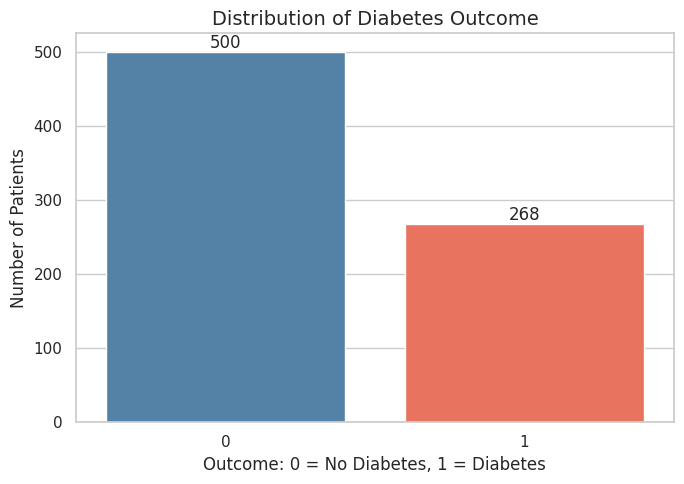

In [14]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",
    palette={
        0: "steelblue",
        1: "tomato"
    },
    legend=False
)

plt.title(
    "Distribution of Diabetes Outcome",
    fontsize=14
)

plt.xlabel(
    "Outcome: 0 = No Diabetes, 1 = Diabetes"
)

plt.ylabel("Number of Patients")

for container_item in ax.containers:
    ax.bar_label(container_item)

plt.tight_layout()
plt.show()

In [15]:
minority_class_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .min()
    * 100
)

majority_class_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .max()
    * 100
)

print(
    f"Majority class percentage: "
    f"{majority_class_percentage:.2f}%"
)

print(
    f"Minority class percentage: "
    f"{minority_class_percentage:.2f}%"
)

if minority_class_percentage < 20:
    imbalance_observation = (
        "The dataset has severe class imbalance."
    )
elif minority_class_percentage < 35:
    imbalance_observation = (
        "The dataset has moderate class imbalance."
    )
else:
    imbalance_observation = (
        "The dataset does not have severe class imbalance."
    )

print(f"Observation: {imbalance_observation}")

Majority class percentage: 65.10%
Minority class percentage: 34.90%
Observation: The dataset has moderate class imbalance.


In [16]:
zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_value_summary = pd.DataFrame({
    "Zero Count": (
        df[zero_as_missing_columns] == 0
    ).sum(),
    
    "Zero Percentage": (
        (
            df[zero_as_missing_columns] == 0
        ).mean()
        * 100
    )
})

zero_value_summary = zero_value_summary.sort_values(
    by="Zero Count",
    ascending=False
)

display(zero_value_summary)

print(
    "These zero values will be treated as missing "
    "medical measurements."
)

,Zero Count,Zero Percentage
Insulin,374,48.698
SkinThickness,227,29.557
BloodPressure,35,4.557
BMI,11,1.432
Glucose,5,0.651


These zero values will be treated as missing medical measurements.


In [17]:
model_df = df.copy()

print("A separate copy was created for preprocessing.")
print(
    "The original DataFrame remains available as df."
)

A separate copy was created for preprocessing.
The original DataFrame remains available as df.


In [18]:
model_df[zero_as_missing_columns] = (
    model_df[zero_as_missing_columns]
    .replace(0, np.nan)
)

missing_after_zero_replacement = pd.DataFrame({
    "Missing Count": model_df.isnull().sum(),
    "Missing Percentage": (
        model_df.isnull().mean() * 100
    )
})

display(missing_after_zero_replacement)

print(
    "Invalid zero measurements were converted to NaN."
)

print(
    "Median imputation will be applied later "
    "inside the Machine "
)

,Missing Count,Missing Percentage
Pregnancies,0,0.000
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


Invalid zero measurements were converted to NaN.
Median imputation will be applied later inside the Machine 


In [19]:
model_df["Glucose_BMI_Interaction"] = (
    model_df["Glucose"]
    * model_df["BMI"]
)

model_df["Age_BMI_Interaction"] = (
    model_df["Age"]
    * model_df["BMI"]
)

model_df["Glucose_Age_Interaction"] = (
    model_df["Glucose"]
    * model_df["Age"]
)

print("Created engineered features:")
print("1. Glucose_BMI_Interaction")
print("2. Age_BMI_Interaction")
print("3. Glucose_Age_Interaction")

display(model_df.head())

Created engineered features:
1. Glucose_BMI_Interaction
2. Age_BMI_Interaction
3. Glucose_Age_Interaction


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Interaction,Age_BMI_Interaction,Glucose_Age_Interaction
0,6,148.000,72.000,35.000,NaN,33.600,0.627,50,1,4972.800,1680.000,7400.000
1,1,85.000,66.000,29.000,NaN,26.600,0.351,31,0,2261.000,824.600,2635.000
2,8,183.000,64.000,NaN,NaN,23.300,0.672,32,1,4263.900,745.600,5856.000
3,1,89.000,66.000,23.000,94.000,28.100,0.167,21,0,2500.900,590.100,1869.000
4,0,137.000,40.000,35.000,168.000,43.100,2.288,33,1,5904.700,1422.300,4521.000


In [20]:
print(
    "Statistical summary after converting "
    "invalid zeros to missing values"
)

display(
    model_df.describe().T
)

Statistical summary after converting invalid zeros to missing values


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,763.000,121.687,30.536,44.000,99.000,117.000,141.000,199.000
BloodPressure,733.000,72.405,12.382,24.000,64.000,72.000,80.000,122.000
SkinThickness,541.000,29.153,10.477,7.000,22.000,29.000,36.000,99.000
Insulin,394.000,155.548,118.776,14.000,76.250,125.000,190.000,846.000
BMI,757.000,32.457,6.925,18.200,27.500,32.300,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000
Glucose_BMI_Interaction,752.000,4006.858,1480.170,1100.000,2924.100,3773.450,4841.775,10692.000


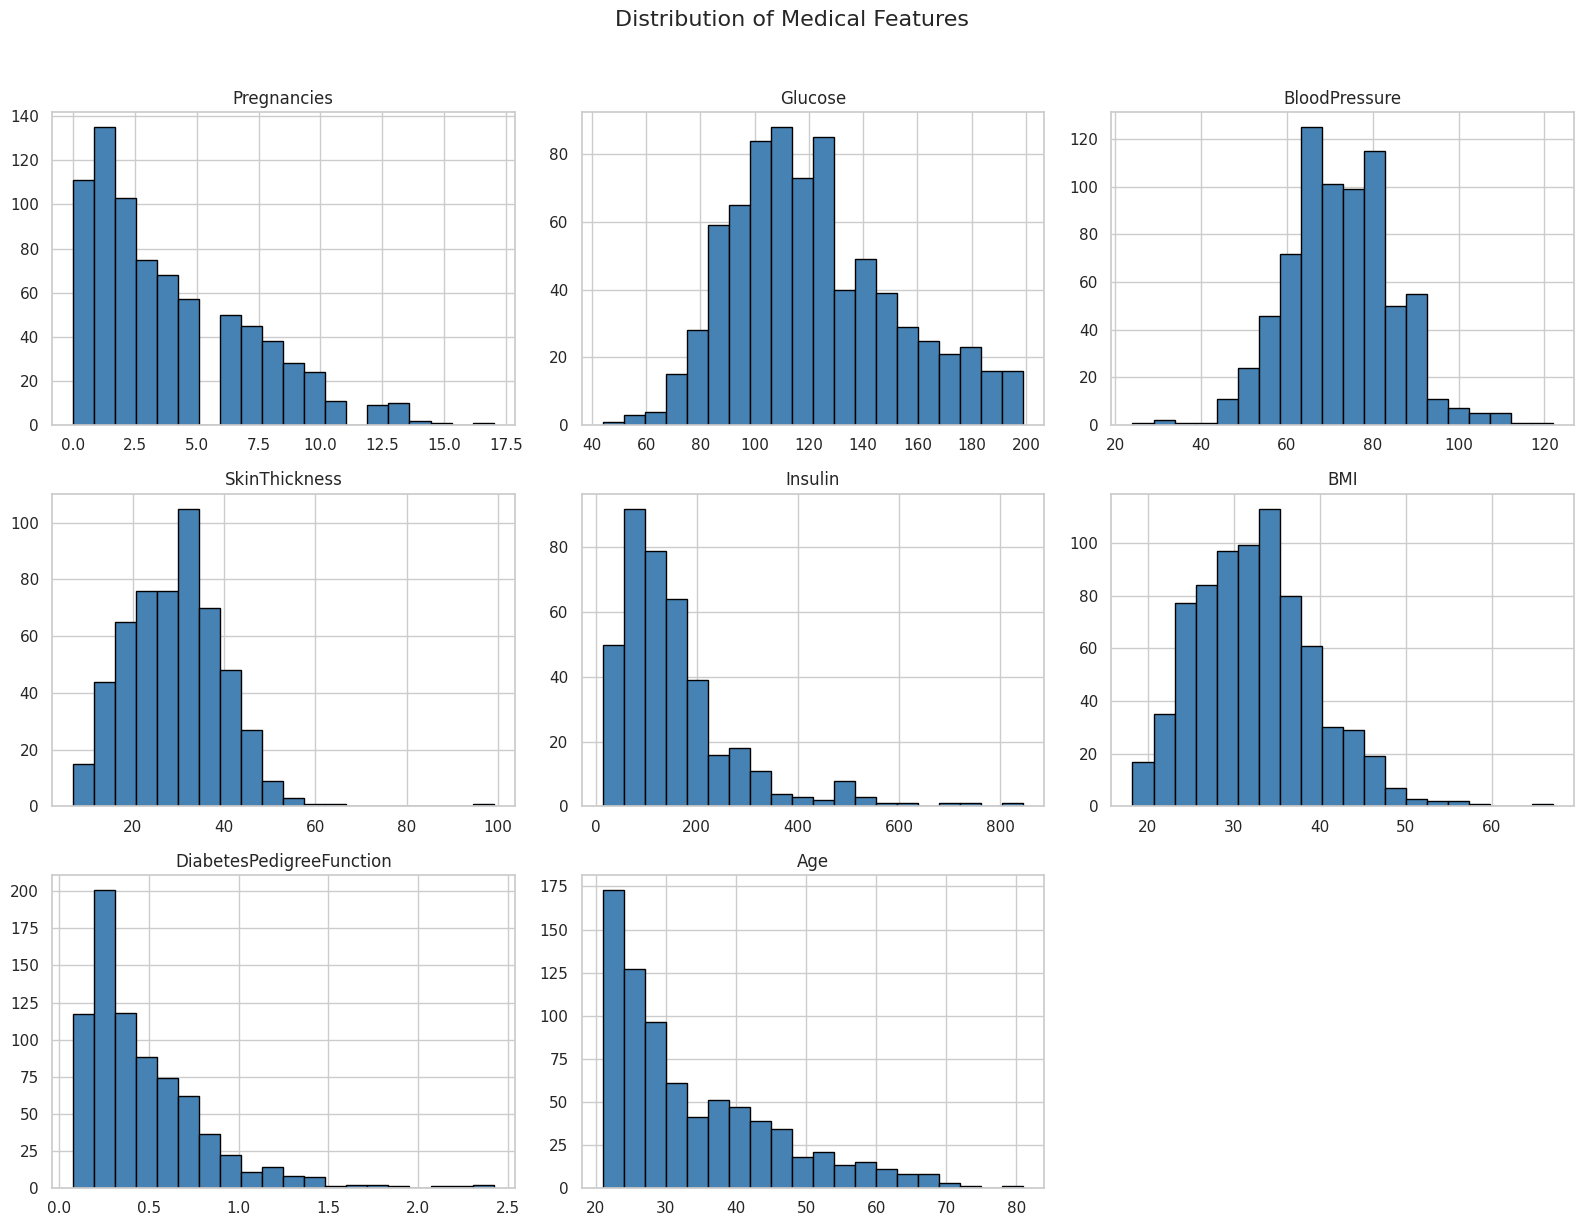

In [21]:
original_feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

model_df[original_feature_columns].hist(
    bins=20,
    figsize=(16, 12),
    color="steelblue",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Medical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

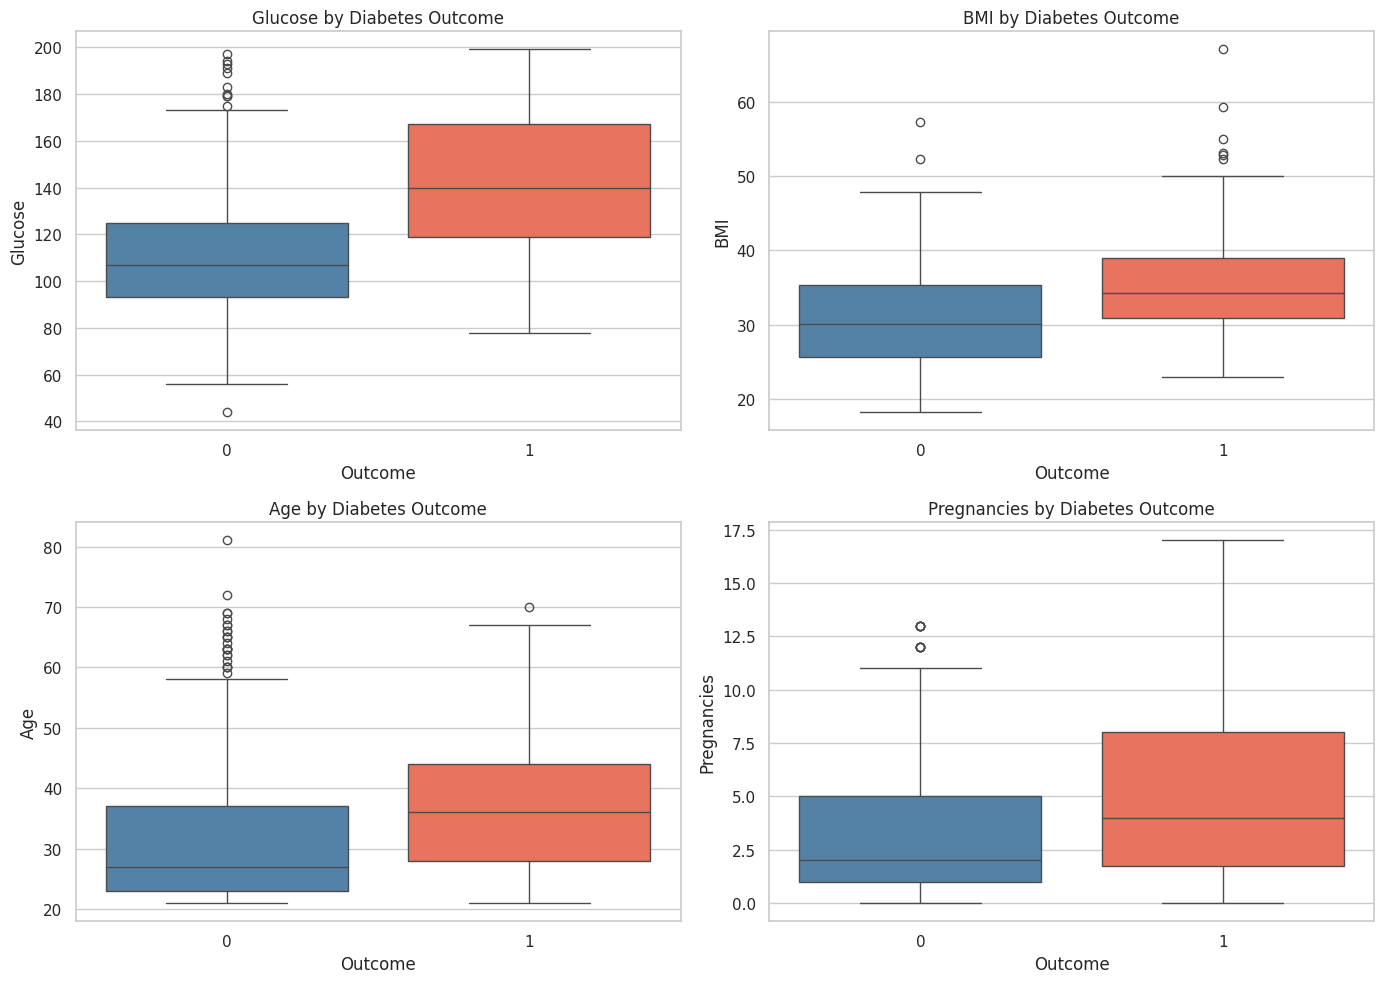

In [22]:
important_eda_features = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies"
]

figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for position, feature in enumerate(
    important_eda_features
):
    sns.boxplot(
        data=model_df,
        x="Outcome",
        y=feature,
        hue="Outcome",
        palette={
            0: "steelblue",
            1: "tomato"
        },
        legend=False,
        ax=axes[position]
    )
    
    axes[position].set_title(
        f"{feature} by Diabetes Outcome"
    )
    
    axes[position].set_xlabel(
        "Outcome"
    )
    
    axes[position].set_ylabel(
        feature
    )

plt.tight_layout()
plt.show()

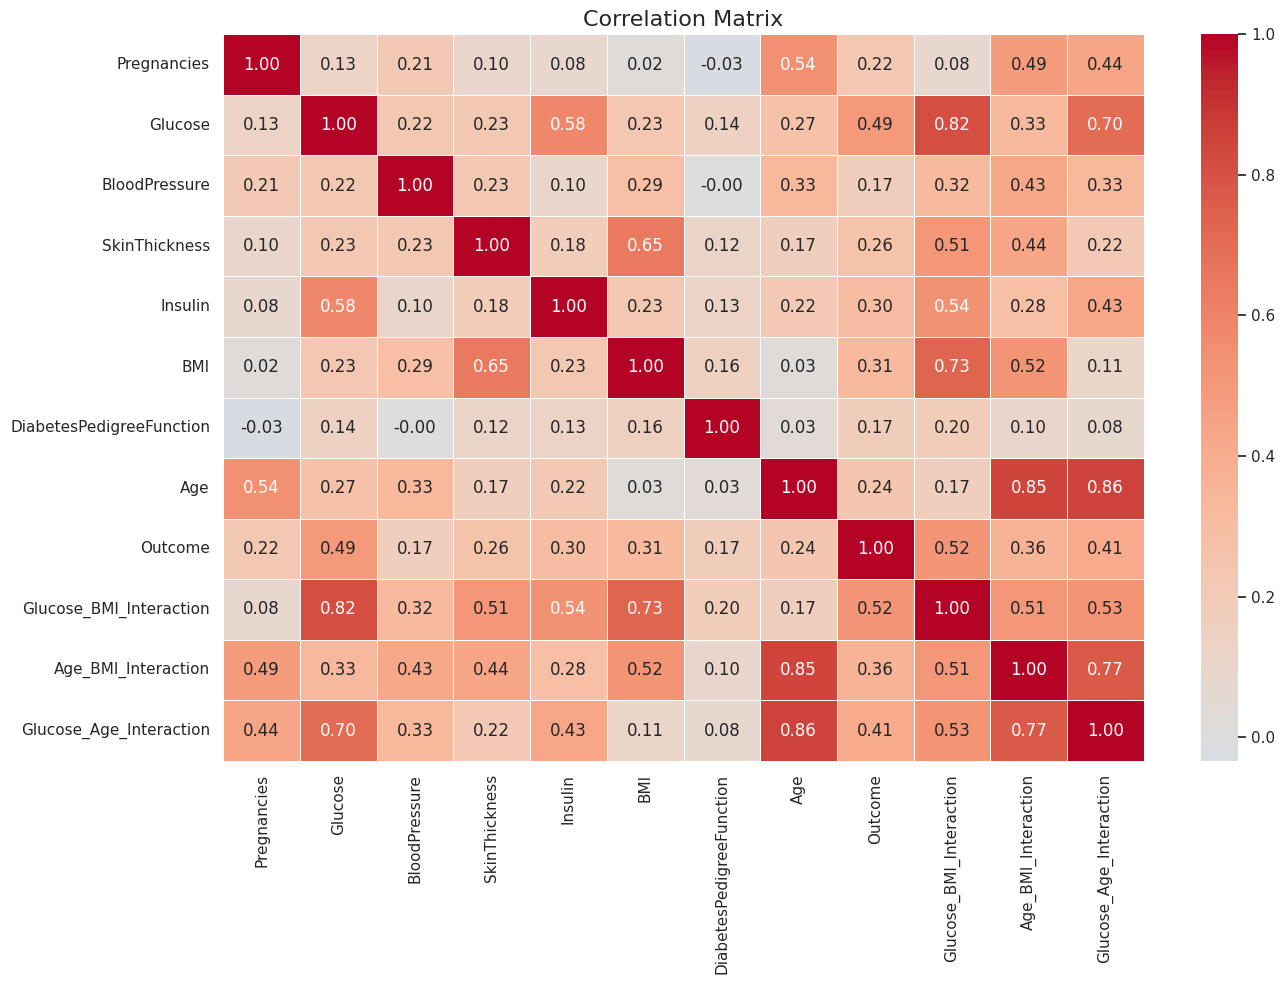

In [23]:
correlation_matrix = model_df.corr(
    numeric_only=True
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [24]:
outcome_correlation = (
    correlation_matrix["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
    .to_frame(name="Correlation with Outcome")
)

display(outcome_correlation)

highest_correlated_feature = (
    outcome_correlation
    .abs()
    .sort_values(
        by="Correlation with Outcome",
        ascending=False
    )
    .index[0]
)

print(
    "Feature with the strongest absolute "
    f"correlation with Outcome: "
    f"{highest_correlated_feature}"
)

,Correlation with Outcome
Glucose_BMI_Interaction,0.519
Glucose,0.495
Glucose_Age_Interaction,0.409
Age_BMI_Interaction,0.363
BMI,0.314
Insulin,0.303
SkinThickness,0.259
Age,0.238
Pregnancies,0.222
DiabetesPedigreeFunction,0.174


Feature with the strongest absolute correlation with Outcome: Glucose_BMI_Interaction


In [25]:
X = model_df.drop(
    columns=["Outcome"]
)

y = model_df["Outcome"].astype(int)

print(f"Feature dataset shape: {X.shape}")
print(f"Target dataset shape: {y.shape}")

print("\nFeature columns:")

for position, feature in enumerate(
    X.columns,
    start=1
):
    print(f"{position}. {feature}")

print("\nTarget variable: Outcome")
print("0 = No Diabetes")
print("1 = Diabetes")

Feature dataset shape: (768, 11)
Target dataset shape: (768,)

Feature columns:
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Glucose_BMI_Interaction
10. Age_BMI_Interaction
11. Glucose_Age_Interaction

Target variable: Outcome
0 = No Diabetes
1 = Diabetes


In [26]:
class_counts = y.value_counts()

minimum_class_count = int(
    class_counts.min()
)

print("Target class counts:")
display(
    class_counts
    .sort_index()
    .to_frame(name="Count")
)

if minimum_class_count < 2:
    raise ValueError(
        "Each target class must have at least two "
        "records for a stratified train-test split."
    )

print(
    "The dataset supports a stratified "
    "train-test split."
)

Target class counts:


,Count
Outcome,
0,500
1,268


The dataset supports a stratified train-test split.


In [27]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

print(f"Complete dataset size: {len(X)}")
print(f"Training dataset size: {len(X_train)}")
print(f"Testing dataset size: {len(X_test)}")

print(
    f"Training percentage: "
    f"{len(X_train) / len(X) * 100:.2f}%"
)

print(
    f"Testing percentage: "
    f"{len(X_test) / len(X) * 100:.2f}%"
)

Complete dataset size: 768
Training dataset size: 576
Testing dataset size: 192
Training percentage: 75.00%
Testing percentage: 25.00%


In [28]:
training_distribution = pd.DataFrame({
    "Count": (
        y_train
        .value_counts()
        .sort_index()
    ),
    
    "Percentage": (
        y_train
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

testing_distribution = pd.DataFrame({
    "Count": (
        y_test
        .value_counts()
        .sort_index()
    ),
    
    "Percentage": (
        y_test
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

print("Training target distribution")
display(training_distribution)

print("Testing target distribution")
display(testing_distribution)

Training target distribution


,Count,Percentage
Outcome,,
0,375,65.104
1,201,34.896


Testing target distribution


,Count,Percentage
Outcome,,
0,125,65.104
1,67,34.896


In [29]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=6,
                min_samples_split=8,
                min_samples_leaf=4,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print(
    "Random Forest pipeline created successfully."
)

print("\nPipeline steps:")

for step_name, step_object in (
    random_forest_pipeline.steps
):
    print(f"{step_name}: {step_object}")

Random Forest pipeline created successfully.

Pipeline steps:
median_imputer: SimpleImputer(strategy='median')
random_forest: RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=4,
                       min_samples_split=8, n_estimators=500, n_jobs=-1,
                       random_state=42)


In [30]:
model_explanation = """
SELECTED MODEL: RANDOM FOREST CLASSIFIER

Why Random Forest is suitable:

1. The target variable is binary, so this is a classification problem.

2. Random Forest can capture nonlinear relationships between medical
   measurements and diabetes.

3. It can identify interactions between features such as Glucose,
   BMI, Age, Insulin, and Diabetes Pedigree Function.

4. It is less sensitive to outliers than many linear models.

5. It does not require numerical feature scaling.

6. It is more resistant to overfitting than a single Decision Tree.

7. It provides feature importance scores that help explain which
   attributes influence predictions.

How Random Forest makes predictions:

1. It creates multiple Decision Trees.

2. Each tree is trained using a different sample of the training data.

3. Each split considers a randomly selected subset of features.

4. Every Decision Tree predicts either class 0 or class 1.

5. The final classification is based on majority voting across all trees.

Key model parameters:

n_estimators = 500
Creates 500 Decision Trees.

max_depth = 6
Restricts the depth of individual trees to control overfitting.

min_samples_split = 8
A node requires at least eight records before it can be split.

min_samples_leaf = 4
Each final leaf must contain at least four records.

max_features = sqrt
Each split considers the square root of the total number of features.

class_weight = balanced
Automatically gives more importance to the minority class.

random_state = 42
Makes the results reproducible.

n_jobs = -1
Uses all available processor cores.
"""

print(model_explanation)


SELECTED MODEL: RANDOM FOREST CLASSIFIER

Why Random Forest is suitable:

1. The target variable is binary, so this is a classification problem.

2. Random Forest can capture nonlinear relationships between medical
   measurements and diabetes.

3. It can identify interactions between features such as Glucose,
   BMI, Age, Insulin, and Diabetes Pedigree Function.

4. It is less sensitive to outliers than many linear models.

5. It does not require numerical feature scaling.

6. It is more resistant to overfitting than a single Decision Tree.

7. It provides feature importance scores that help explain which
   attributes influence predictions.

How Random Forest makes predictions:

1. It creates multiple Decision Trees.

2. Each tree is trained using a different sample of the training data.

3. Each split considers a randomly selected subset of features.

4. Every Decision Tree predicts either class 0 or class 1.

5. The final classification is based on majority voting across all trees

In [31]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")
print(f"Number of training records used: {len(X_train)}")
print(f"Number of features used: {X_train.shape[1]}")

Random Forest model trained successfully.
Number of training records used: 576
Number of features used: 11


In [32]:
trained_imputer = random_forest_pipeline.named_steps["median_imputer"]

imputation_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Training_Median_Used": trained_imputer.statistics_
})

display(imputation_summary)

print("The median values were calculated using only the training dataset.")
print("This prevents information leakage from the testing dataset.")

,Feature,Training_Median_Used
0,Pregnancies,3.000
1,Glucose,117.000
2,BloodPressure,72.000
3,SkinThickness,29.000
4,Insulin,125.000
5,BMI,32.400
6,DiabetesPedigreeFunction,0.384
7,Age,30.000
8,Glucose_BMI_Interaction,3796.200
9,Age_BMI_Interaction,1000.500


The median values were calculated using only the training dataset.
This prevents information leakage from the testing dataset.


In [33]:
y_train_pred = random_forest_pipeline.predict(X_train)
y_test_pred = random_forest_pipeline.predict(X_test)

y_train_probability = random_forest_pipeline.predict_proba(X_train)[:, 1]
y_test_probability = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Training predictions generated:", len(y_train_pred))
print("Testing predictions generated:", len(y_test_pred))
print("Training probabilities generated:", len(y_train_probability))
print("Testing probabilities generated:", len(y_test))

Training predictions generated: 576
Testing predictions generated: 192
Training probabilities generated: 576
Testing probabilities generated: 192


In [34]:
def calculate_classification_metrics(actual_values, predicted_values, predicted_probabilities):
    accuracy = accuracy_score(actual_values, predicted_values)
    
    precision = precision_score(
        actual_values,
        predicted_values,
        zero_division=0
    )
    
    recall = recall_score(
        actual_values,
        predicted_values,
        zero_division=0
    )
    
    f1 = f1_score(
        actual_values,
        predicted_values,
        zero_division=0
    )
    
    if len(np.unique(actual_values)) == 2:
        roc_auc = roc_auc_score(
            actual_values,
            predicted_probabilities
        )
    else:
        roc_auc = np.nan
    
    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }
    
    return metrics


print("Classification evaluation function created successfully.")

Classification evaluation function created successfully.


In [35]:
training_metrics = calculate_classification_metrics(
    actual_values=y_train,
    predicted_values=y_train_pred,
    predicted_probabilities=y_train_probability
)

training_performance = pd.DataFrame(
    [training_metrics],
    index=["Training Performance"]
)

display(
    training_performance.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Training Performance,0.852,0.744,0.881,0.806,0.948


In [36]:
print("TRAINING CLASSIFICATION REPORT")
print("=" * 70)

training_classification_report = classification_report(
    y_train,
    y_train_pred,
    labels=[0, 1],
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
)

print(training_classification_report)

TRAINING CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.93      0.84      0.88       375
    Diabetes       0.74      0.88      0.81       201

    accuracy                           0.85       576
   macro avg       0.84      0.86      0.84       576
weighted avg       0.86      0.85      0.85       576



In [37]:
testing_metrics = calculate_classification_metrics(
    actual_values=y_test,
    predicted_values=y_test_pred,
    predicted_probabilities=y_test_probability
)

testing_performance = pd.DataFrame(
    [testing_metrics],
    index=["Testing Performance"]
)

display(
    testing_performance.style.format(
        {
            "Accuracy": "{:.3f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1-Score": "{:.3f}",
            "ROC-AUC": "{:.3f}"
        }
    )
)

print("Testing performance calculated successfully.")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Testing Performance,0.750,0.620,0.731,0.671,0.826


Testing performance calculated successfully.


In [38]:
print("TESTING CLASSIFICATION REPORT")
print("=" * 70)

testing_classification_report = classification_report(
    y_true=y_test,
    y_pred=y_test_pred,
    labels=[0, 1],
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
)

print(testing_classification_report)

TESTING CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.84      0.76      0.80       125
    Diabetes       0.62      0.73      0.67        67

    accuracy                           0.75       192
   macro avg       0.73      0.75      0.73       192
weighted avg       0.76      0.75      0.75       192



In [39]:
performance_comparison = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ],
        "Training": [
            training_metrics["Accuracy"],
            training_metrics["Precision"],
            training_metrics["Recall"],
            training_metrics["F1-Score"],
            training_metrics["ROC-AUC"]
        ],
        "Testing": [
            testing_metrics["Accuracy"],
            testing_metrics["Precision"],
            testing_metrics["Recall"],
            testing_metrics["F1-Score"],
            testing_metrics["ROC-AUC"]
        ]
    }
)

performance_comparison["Difference"] = (
    performance_comparison["Training"]
    - performance_comparison["Testing"]
)

display(
    performance_comparison.style.format(
        {
            "Training": "{:.3f}",
            "Testing": "{:.3f}",
            "Difference": "{:.3f}"
        }
    )
)

print(
    "A positive difference means training performance is higher "
    "than testing performance."
)

,Metric,Training,Testing,Difference
0,Accuracy,0.852,0.750,0.102
1,Precision,0.744,0.620,0.123
2,Recall,0.881,0.731,0.149
3,F1-Score,0.806,0.671,0.135
4,ROC-AUC,0.948,0.826,0.122


A positive difference means training performance is higher than testing performance.


<function matplotlib.pyplot.show(close=None, block=None)>

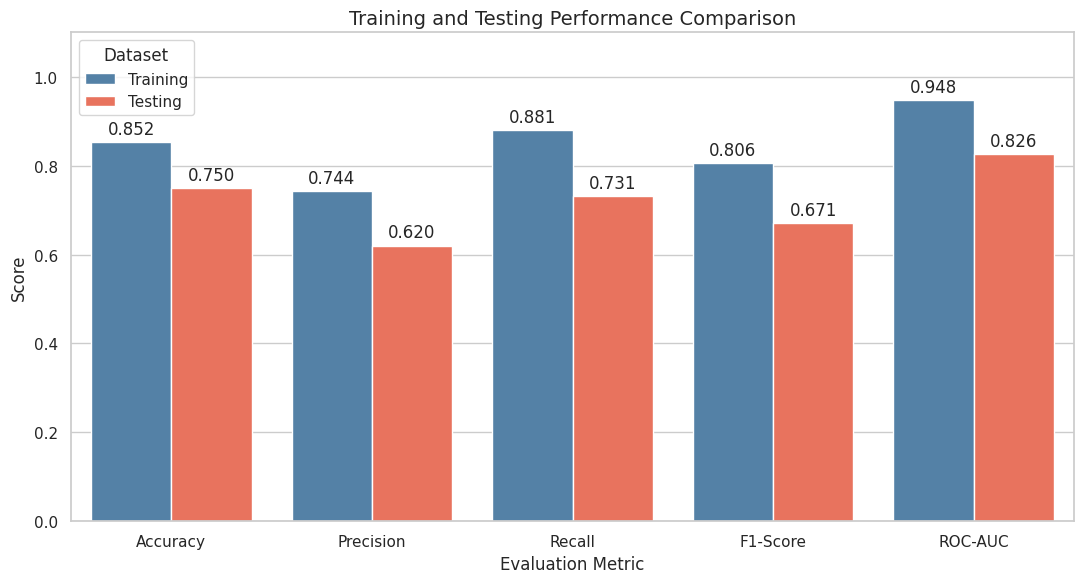

In [40]:
performance_plot_data = performance_comparison.melt(
    id_vars="Metric",
    value_vars=["Training", "Testing"],
    var_name="Dataset",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

performance_axis = sns.barplot(
    data=performance_plot_data,
    x="Metric",
    y="Score",
    hue="Dataset",
    palette={
        "Training": "steelblue",
        "Testing": "tomato"
    }
)

plt.title(
    "Training and Testing Performance Comparison",
    fontsize=14
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.10)
plt.legend(title="Dataset")

for bar_container in performance_axis.containers:
    performance_axis.bar_label(
        bar_container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show

In [41]:
test_confusion_matrix = confusion_matrix(
    y_true=y_test,
    y_pred=y_test_pred,
    labels=[0, 1]
)

true_negative = int(
    test_confusion_matrix[0, 0]
)

false_positive = int(
    test_confusion_matrix[0, 1]
)

false_negative = int(
    test_confusion_matrix[1, 0]
)

true_positive = int(
    test_confusion_matrix[1, 1]
)

confusion_matrix_analysis = pd.DataFrame(
    {
        "Component": [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive"
        ],
        "Abbreviation": [
            "TN",
            "FP",
            "FN",
            "TP"
        ],
        "Meaning": [
            "No-diabetes patient correctly predicted as no diabetes",
            "No-diabetes patient incorrectly predicted as diabetic",
            "Diabetes patient incorrectly predicted as not diabetic",
            "Diabetes patient correctly predicted as diabetic"
        ],
        "Count": [
            true_negative,
            false_positive,
            false_negative,
            true_positive
        ]
    }
)

print("Testing confusion matrix:")
display(
    pd.DataFrame(
        test_confusion_matrix,
        index=[
            "Actual No Diabetes",
            "Actual Diabetes"
        ],
        columns=[
            "Predicted No Diabetes",
            "Predicted Diabetes"
        ]
    )
)

print("Confusion matrix component analysis:")
display(confusion_matrix_analysis)

Testing confusion matrix:


,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,95,30
Actual Diabetes,18,49


Confusion matrix component analysis:


,Component,Abbreviation,Meaning,Count
0,True Negative,TN,No-diabetes patient correctly predicted as no ...,95
1,False Positive,FP,No-diabetes patient incorrectly predicted as d...,30
2,False Negative,FN,Diabetes patient incorrectly predicted as not ...,18
3,True Positive,TP,Diabetes patient correctly predicted as diabetic,49


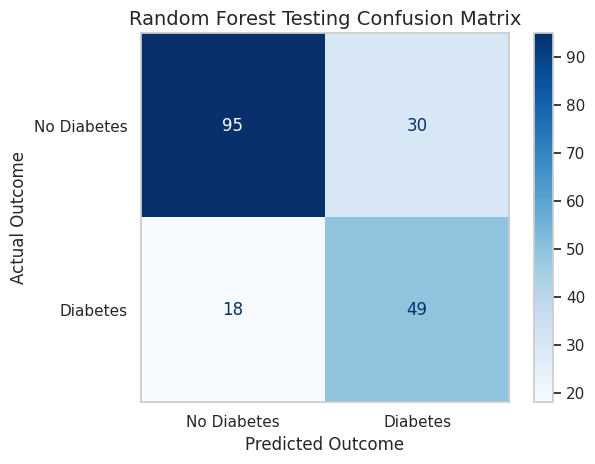

In [42]:
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

confusion_matrix_display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Random Forest Testing Confusion Matrix",
    fontsize=14
)

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.grid(False)
plt.tight_layout()
plt.show()

In [43]:
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 70)

print(f"True Negatives: {true_negative}")

print(
    "These patients did not have diabetes, and the model "
    "correctly predicted that they did not have diabetes."
)

print()

print(f"False Positives: {false_positive}")

print(
    "These patients did not have diabetes, but the model "
    "incorrectly predicted that they had diabetes."
)

print()

print(f"False Negatives: {false_negative}")

print(
    "These patients had diabetes, but the model incorrectly "
    "predicted that they did not have diabetes."
)

print()

print(f"True Positives: {true_positive}")

print(
    "These patients had diabetes, and the model correctly "
    "predicted that they had diabetes."
)

print()

print("Important observation:")

print(
    "False negatives are particularly important because they "
    "represent patients with diabetes who were missed by the model."
)

CONFUSION MATRIX INTERPRETATION
True Negatives: 95
These patients did not have diabetes, and the model correctly predicted that they did not have diabetes.

False Positives: 30
These patients did not have diabetes, but the model incorrectly predicted that they had diabetes.

False Negatives: 18
These patients had diabetes, but the model incorrectly predicted that they did not have diabetes.

True Positives: 49
These patients had diabetes, and the model correctly predicted that they had diabetes.

Important observation:
False negatives are particularly important because they represent patients with diabetes who were missed by the model.


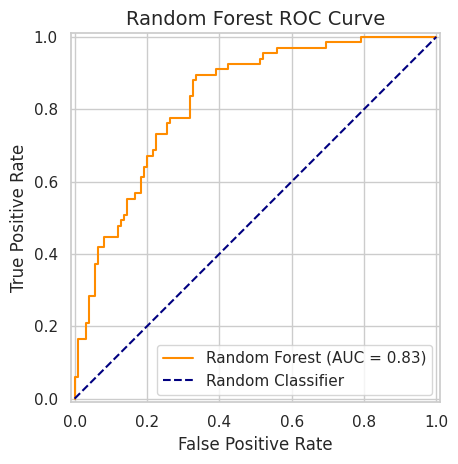

Testing ROC-AUC score: 0.826


In [44]:
unique_test_classes = np.unique(y_test)

if len(unique_test_classes) == 2:
    roc_display = RocCurveDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_test_probability,
        name="Random Forest",
        color="darkorange"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="navy",
        label="Random Classifier"
    )

    plt.title(
        "Random Forest ROC Curve",
        fontsize=14
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Testing ROC-AUC score: "
        f"{testing_metrics['ROC-AUC']:.3f}"
    )

else:
    print(
        "The ROC curve cannot be generated because the testing "
        "dataset does not contain both target classes."
    )

In [45]:
training_accuracy = training_metrics["Accuracy"]
testing_accuracy = testing_metrics["Accuracy"]

training_f1 = training_metrics["F1-Score"]
testing_f1 = testing_metrics["F1-Score"]

accuracy_gap = (
    training_accuracy
    - testing_accuracy
)

f1_gap = (
    training_f1
    - testing_f1
)

absolute_accuracy_gap = abs(
    accuracy_gap
)

absolute_f1_gap = abs(
    f1_gap
)

print("OVERFITTING AND UNDERFITTING ANALYSIS")
print("=" * 70)

print(
    f"Training accuracy: "
    f"{training_accuracy:.3f}"
)

print(
    f"Testing accuracy: "
    f"{testing_accuracy:.3f}"
)

print(
    f"Training minus testing accuracy: "
    f"{accuracy_gap:.3f}"
)

print(
    f"Absolute accuracy difference: "
    f"{absolute_accuracy_gap:.3f}"
)

print()

print(
    f"Training F1-score: "
    f"{training_f1:.3f}"
)

print(
    f"Testing F1-score: "
    f"{testing_f1:.3f}"
)

print(
    f"Training minus testing F1-score: "
    f"{f1_gap:.3f}"
)

print(
    f"Absolute F1-score difference: "
    f"{absolute_f1_gap:.3f}"
)

if (
    training_accuracy < 0.70
    and testing_accuracy < 0.70
):
    fit_observation = (
        "The model may be underfitting because both training "
        "and testing accuracy are relatively low."
    )

elif (
    accuracy_gap > 0.10
    or f1_gap > 0.10
):
    fit_observation = (
        "The model shows signs of overfitting because training "
        "performance is considerably higher than testing performance."
    )

elif testing_accuracy - training_accuracy > 0.10:
    fit_observation = (
        "Testing accuracy is considerably higher than training "
        "accuracy. This may be caused by sampling variation or "
        "an unusually easy testing subset."
    )

else:
    fit_observation = (
        "Training and testing performance are reasonably close. "
        "There is no strong indication of overfitting or underfitting."
    )

print()
print(f"Observation: {fit_observation}")

OVERFITTING AND UNDERFITTING ANALYSIS
Training accuracy: 0.852
Testing accuracy: 0.750
Training minus testing accuracy: 0.102
Absolute accuracy difference: 0.102

Training F1-score: 0.806
Testing F1-score: 0.671
Training minus testing F1-score: 0.135
Absolute F1-score difference: 0.135

Observation: The model shows signs of overfitting because training performance is considerably higher than testing performance.


In [46]:
trained_random_forest = (
    random_forest_pipeline
    .named_steps["random_forest"]
)

feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": trained_random_forest.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.insert(
    loc=0,
    column="Rank",
    value=range(
        1,
        len(feature_importance) + 1
    )
)

print("Random Forest feature importance:")
display(
    feature_importance.style.format(
        {
            "Importance": "{:.4f}"
        }
    )
)

importance_total = feature_importance["Importance"].sum()

print(
    f"Total feature importance: "
    f"{importance_total:.4f}"
)

Random Forest feature importance:


,Rank,Feature,Importance
0,1,Glucose_BMI_Interaction,0.2346
1,2,Glucose_Age_Interaction,0.2001
2,3,Glucose,0.1487
3,4,Age_BMI_Interaction,0.1047
4,5,BMI,0.0821
5,6,Age,0.0543
6,7,DiabetesPedigreeFunction,0.0534
7,8,Insulin,0.0461
8,9,Pregnancies,0.0304
9,10,BloodPressure,0.0229


Total feature importance: 1.0000


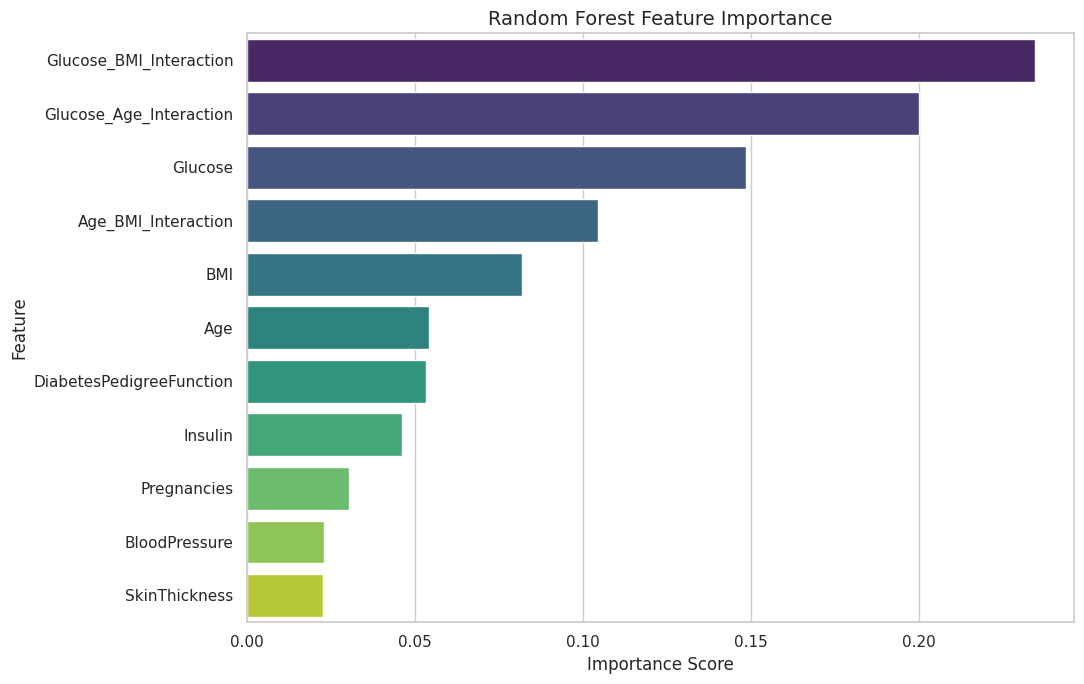

In [47]:
plt.figure(figsize=(11, 7))

feature_importance_axis = sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=14
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [48]:
top_five_features = feature_importance.head(5).copy()

print("FIVE MOST INFLUENTIAL FEATURES")
print("=" * 70)

for _, feature_row in top_five_features.iterrows():
    feature_rank = int(
        feature_row["Rank"]
    )

    feature_name = feature_row["Feature"]

    feature_score = feature_row["Importance"]

    print(
        f"{feature_rank}. "
        f"{feature_name}: "
        f"{feature_score:.4f}"
    )

print()

print(
    "Feature importance represents predictive influence in the "
    "Random Forest model. It does not establish medical causation."
)

FIVE MOST INFLUENTIAL FEATURES
1. Glucose_BMI_Interaction: 0.2346
2. Glucose_Age_Interaction: 0.2001
3. Glucose: 0.1487
4. Age_BMI_Interaction: 0.1047
5. BMI: 0.0821

Feature importance represents predictive influence in the Random Forest model. It does not establish medical causation.


In [49]:
test_results = X_test.copy()

test_results["Actual_Outcome"] = (
    y_test.to_numpy()
)

test_results["Predicted_Outcome"] = (
    y_test_pred
)

test_results["No_Diabetes_Probability"] = (
    1 - y_test_probability
)

test_results["Diabetes_Probability"] = (
    y_test_probability
)

test_results["Actual_Label"] = (
    test_results["Actual_Outcome"]
    .map(
        {
            0: "No Diabetes",
            1: "Diabetes"
        }
    )
)

test_results["Predicted_Label"] = (
    test_results["Predicted_Outcome"]
    .map(
        {
            0: "No Diabetes",
            1: "Diabetes"
        }
    )
)

test_results["Prediction_Correct"] = (
    test_results["Actual_Outcome"]
    == test_results["Predicted_Outcome"]
)

test_results = test_results.sort_values(
    by="Diabetes_Probability",
    ascending=False
)

print("Patient-level testing results:")
display(test_results)

Patient-level testing results:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI_Interaction,Age_BMI_Interaction,Glucose_Age_Interaction,Actual_Outcome,Predicted_Outcome,No_Diabetes_Probability,Diabetes_Probability,Actual_Label,Predicted_Label,Prediction_Correct
761,9,170.000,74.000,31.000,NaN,44.000,0.403,43,7480.000,1892.000,7310.000,1,1,0.057,0.943,Diabetes,Diabetes,True
185,7,194.000,68.000,28.000,NaN,35.900,0.745,41,6964.600,1471.900,7954.000,1,1,0.068,0.932,Diabetes,Diabetes,True
235,4,171.000,72.000,NaN,NaN,43.600,0.479,26,7455.600,1133.600,4446.000,1,1,0.076,0.924,Diabetes,Diabetes,True
359,1,196.000,76.000,36.000,249.000,36.500,0.875,29,7154.000,1058.500,5684.000,1,1,0.081,0.919,Diabetes,Diabetes,True
335,0,165.000,76.000,43.000,255.000,47.900,0.259,26,7903.500,1245.400,4290.000,0,1,0.085,0.915,No Diabetes,Diabetes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,0,73.000,NaN,NaN,NaN,21.100,0.342,25,1540.300,527.500,1825.000,0,0,0.993,0.007,No Diabetes,No Diabetes,True
158,2,88.000,74.000,19.000,53.000,29.000,0.229,22,2552.000,638.000,1936.000,0,0,0.994,0.006,No Diabetes,No Diabetes,True
83,0,101.000,65.000,28.000,NaN,24.600,0.237,22,2484.600,541.200,2222.000,0,0,0.995,0.005,No Diabetes,No Diabetes,True
3,1,89.000,66.000,23.000,94.000,28.100,0.167,21,2500.900,590.100,1869.000,0,0,0.995,0.005,No Diabetes,No Diabetes,True


In [50]:
total_test_predictions = len(
    test_results
)

correct_predictions = int(
    test_results["Prediction_Correct"].sum()
)

incorrect_predictions = int(
    total_test_predictions
    - correct_predictions
)

correct_prediction_percentage = (
    correct_predictions
    / total_test_predictions
    * 100
)

incorrect_prediction_percentage = (
    incorrect_predictions
    / total_test_predictions
    * 100
)

prediction_summary = pd.DataFrame(
    {
        "Measure": [
            "Total Test Predictions",
            "Correct Predictions",
            "Incorrect Predictions",
            "Correct Prediction Percentage",
            "Incorrect Prediction Percentage"
        ],
        "Value": [
            total_test_predictions,
            correct_predictions,
            incorrect_predictions,
            f"{correct_prediction_percentage:.2f}%",
            f"{incorrect_prediction_percentage:.2f}%"
        ]
    }
)

print("Testing prediction summary:")
display(prediction_summary)

Testing prediction summary:


,Measure,Value
0,Total Test Predictions,192
1,Correct Predictions,144
2,Incorrect Predictions,48
3,Correct Prediction Percentage,75.00%
4,Incorrect Prediction Percentage,25.00%


In [51]:
incorrect_prediction_records = test_results.loc[
    test_results["Prediction_Correct"] == False
].copy()

print(
    f"Number of incorrectly classified testing records: "
    f"{len(incorrect_prediction_records)}"
)

if len(incorrect_prediction_records) > 0:
    display(incorrect_prediction_records)

else:
    print(
        "The model correctly classified every record "
        "in the testing dataset."
    )

Number of incorrectly classified testing records: 48


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI_Interaction,Age_BMI_Interaction,Glucose_Age_Interaction,Actual_Outcome,Predicted_Outcome,No_Diabetes_Probability,Diabetes_Probability,Actual_Label,Predicted_Label,Prediction_Correct
335,0,165.000,76.000,43.000,255.000,47.900,0.259,26,7903.500,1245.400,4290.000,0,1,0.085,0.915,No Diabetes,Diabetes,False
212,7,179.000,95.000,31.000,NaN,34.200,0.164,60,6121.800,2052.000,10740.000,0,1,0.113,0.887,No Diabetes,Diabetes,False
645,2,157.000,74.000,35.000,440.000,39.400,0.134,30,6185.800,1182.000,4710.000,0,1,0.123,0.877,No Diabetes,Diabetes,False
260,3,191.000,68.000,15.000,130.000,30.900,0.299,34,5901.900,1050.600,6494.000,0,1,0.124,0.876,No Diabetes,Diabetes,False
247,0,165.000,90.000,33.000,680.000,52.300,0.427,23,8629.500,1202.900,3795.000,0,1,0.153,0.847,No Diabetes,Diabetes,False
469,6,154.000,78.000,41.000,140.000,46.100,0.571,27,7099.400,1244.700,4158.000,0,1,0.186,0.814,No Diabetes,Diabetes,False
436,12,140.000,85.000,33.000,NaN,37.400,0.244,41,5236.000,1533.400,5740.000,0,1,0.188,0.812,No Diabetes,Diabetes,False
489,8,194.000,80.000,NaN,NaN,26.100,0.551,67,5063.400,1748.700,12998.000,0,1,0.237,0.763,No Diabetes,Diabetes,False
244,2,146.000,76.000,35.000,194.000,38.200,0.329,29,5577.200,1107.800,4234.000,0,1,0.260,0.740,No Diabetes,Diabetes,False
44,7,159.000,64.000,NaN,NaN,27.400,0.294,40,4356.600,1096.000,6360.000,0,1,0.270,0.730,No Diabetes,Diabetes,False


In [52]:
print("MOST IMPORTANT PERFORMANCE METRIC: RECALL")
print("=" * 70)

print(
    "Recall is the most important primary performance metric "
    "for this diabetes prediction problem."
)

print()

print(
    "Recall measures the proportion of actual diabetes patients "
    "that the model correctly identifies."
)

print()

print(
    "Recall = True Positives / "
    "(True Positives + False Negatives)"
)

print()

print(
    "A false negative occurs when a patient who has diabetes "
    "is incorrectly classified as not having diabetes."
)

print()

print(
    "In a medical screening problem, a false negative may be "
    "more serious than a false positive because the patient "
    "may not receive timely additional testing or medical attention."
)

print()

print(
    "F1-score should also be considered because it evaluates "
    "the balance between precision and recall."
)

print()

print(
    f"Testing recall achieved by the model: "
    f"{testing_metrics['Recall']:.3f}"
)

print(
    f"Number of false negatives: "
    f"{false_negative}"
)

MOST IMPORTANT PERFORMANCE METRIC: RECALL
Recall is the most important primary performance metric for this diabetes prediction problem.

Recall measures the proportion of actual diabetes patients that the model correctly identifies.

Recall = True Positives / (True Positives + False Negatives)

A false negative occurs when a patient who has diabetes is incorrectly classified as not having diabetes.

In a medical screening problem, a false negative may be more serious than a false positive because the patient may not receive timely additional testing or medical attention.

F1-score should also be considered because it evaluates the balance between precision and recall.

Testing recall achieved by the model: 0.731
Number of false negatives: 18


In [53]:
test_accuracy = testing_metrics["Accuracy"]
test_precision = testing_metrics["Precision"]
test_recall = testing_metrics["Recall"]
test_f1 = testing_metrics["F1-Score"]
test_roc_auc = testing_metrics["ROC-AUC"]

if test_recall >= 0.85:
    recall_interpretation = (
        "The model has high recall and identifies most patients "
        "who have diabetes."
    )

elif test_recall >= 0.70:
    recall_interpretation = (
        "The model has reasonable recall, but some patients with "
        "diabetes are still missed."
    )

else:
    recall_interpretation = (
        "The model has relatively low recall and misses a considerable "
        "proportion of patients who have diabetes."
    )

if test_f1 >= 0.80:
    f1_interpretation = (
        "The model has a strong balance between precision and recall."
    )

elif test_f1 >= 0.65:
    f1_interpretation = (
        "The model has a moderate balance between precision and recall."
    )

else:
    f1_interpretation = (
        "The balance between precision and recall requires improvement."
    )

if pd.isna(test_roc_auc):
    roc_auc_interpretation = (
        "ROC-AUC could not be calculated because both target classes "
        "were not available in the testing dataset."
    )

elif test_roc_auc >= 0.90:
    roc_auc_interpretation = (
        "The ROC-AUC indicates excellent class-separation ability."
    )

elif test_roc_auc >= 0.80:
    roc_auc_interpretation = (
        "The ROC-AUC indicates good class-separation ability."
    )

elif test_roc_auc >= 0.70:
    roc_auc_interpretation = (
        "The ROC-AUC indicates acceptable class-separation ability."
    )

else:
    roc_auc_interpretation = (
        "The ROC-AUC indicates weak class-separation ability."
    )

print("MODEL PERFORMANCE INTERPRETATION")
print("=" * 70)

print(
    f"Testing accuracy: "
    f"{test_accuracy:.3f}"
)

print(
    f"Testing precision: "
    f"{test_precision:.3f}"
)

print(
    f"Testing recall: "
    f"{test_recall:.3f}"
)

print(
    f"Testing F1-score: "
    f"{test_f1:.3f}"
)

if pd.isna(test_roc_auc):
    print(
        "Testing ROC-AUC: "
        "Not available"
    )

else:
    print(
        f"Testing ROC-AUC: "
        f"{test_roc_auc:.3f}"
    )

print()

print(
    f"Recall interpretation: "
    f"{recall_interpretation}"
)

print()

print(
    f"F1-score interpretation: "
    f"{f1_interpretation}"
)

print()

print(
    f"ROC-AUC interpretation: "
    f"{roc_auc_interpretation}"
)

print()

print(
    f"Model fit interpretation: "
    f"{fit_observation}"
)

MODEL PERFORMANCE INTERPRETATION
Testing accuracy: 0.750
Testing precision: 0.620
Testing recall: 0.731
Testing F1-score: 0.671
Testing ROC-AUC: 0.826

Recall interpretation: The model has reasonable recall, but some patients with diabetes are still missed.

F1-score interpretation: The model has a moderate balance between precision and recall.

ROC-AUC interpretation: The ROC-AUC indicates good class-separation ability.

Model fit interpretation: The model shows signs of overfitting because training performance is considerably higher than testing performance.


In [54]:
if len(df) < 100:
    dataset_size_limitation = (
        "The dataset contains fewer than 100 records. "
        "Therefore, the model evaluation metrics may be unstable."
    )

else:
    dataset_size_limitation = (
        "The model was evaluated using a single train-test split. "
        "The results may change when a different split is used."
    )

model_limitations = [
    dataset_size_limitation,
    (
        "Zero values in Glucose, BloodPressure, SkinThickness, "
        "Insulin, and BMI were assumed to represent missing values."
    ),
    (
        "Median imputation may not accurately represent every "
        "patient's actual missing medical measurement."
    ),
    (
        "Random Forest feature importance indicates predictive "
        "influence but does not establish medical causation."
    ),
    (
        "The dataset may not represent patients from all age groups, "
        "locations, ethnicities, or demographic backgrounds."
    ),
    (
        "The final class prediction uses the standard probability "
        "threshold of 0.50."
    ),
    (
        "Only the medical features available in the dataset were used."
    ),
    (
        "The model has not been externally validated using data from "
        "a different patient population."
    ),
    (
        "This model is intended for educational analysis and must not "
        "be treated as a clinical diagnosis system."
    )
]

print("MODEL LIMITATIONS")
print("=" * 70)

for limitation_number, limitation_text in enumerate(
    model_limitations,
    start=1
):
    print(
        f"{limitation_number}. "
        f"{limitation_text}"
    )

MODEL LIMITATIONS
1. The model was evaluated using a single train-test split. The results may change when a different split is used.
2. Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were assumed to represent missing values.
3. Median imputation may not accurately represent every patient's actual missing medical measurement.
4. Random Forest feature importance indicates predictive influence but does not establish medical causation.
5. The dataset may not represent patients from all age groups, locations, ethnicities, or demographic backgrounds.
6. The final class prediction uses the standard probability threshold of 0.50.
7. Only the medical features available in the dataset were used.
8. The model has not been externally validated using data from a different patient population.
9. This model is intended for educational analysis and must not be treated as a clinical diagnosis system.


In [55]:
most_important_feature = (
    feature_importance.iloc[0]["Feature"]
)

most_important_feature_score = (
    feature_importance.iloc[0]["Importance"]
)

top_three_feature_names = (
    feature_importance
    .head(3)["Feature"]
    .tolist()
)

top_three_feature_text = ", ".join(
    top_three_feature_names
)

if pd.isna(test_roc_auc):
    test_roc_auc_text = "Not available"

else:
    test_roc_auc_text = (
        f"{test_roc_auc:.3f}"
    )

if pd.isna(
    training_metrics["ROC-AUC"]
):
    training_roc_auc_text = "Not available"

else:
    training_roc_auc_text = (
        f"{training_metrics['ROC-AUC']:.3f}"
    )

print("=" * 90)
print("FINAL DIABETES PREDICTION MODEL CONCLUSION")
print("=" * 90)

print()

print("1. DATASET AND PREPROCESSING SUMMARY")
print("-" * 90)

print(
    f"The processed diabetes dataset contained {len(df)} patient "
    f"records and {len(expected_columns)} original columns."
)

print(
    "Outcome was selected as the target variable, where 0 represents "
    "No Diabetes and 1 represents Diabetes."
)

print(
    "Zero values in Glucose, BloodPressure, SkinThickness, Insulin, "
    "and BMI were treated as missing medical measurements."
)

print(
    "Missing medical measurements were handled using median "
    "imputation inside the Machine Learning pipeline."
)

print(
    "Three interaction features were created: "
    "Glucose_BMI_Interaction, Age_BMI_Interaction, and "
    "Glucose_Age_Interaction."
)

print(
    f"The dataset was divided into {len(X_train)} training records "
    f"and {len(X_test)} testing records using a stratified "
    f"train-test split."
)

print()

print("2. SELECTED MACHINE LEARNING MODEL")
print("-" * 90)

print(
    "Random Forest Classifier was selected as the only "
    "Machine Learning model."
)

print(
    "Random Forest was selected because it can model nonlinear "
    "relationships, capture interactions between medical variables, "
    "control overfitting, and provide feature importance scores."
)

print()

print("3. TRAINING PERFORMANCE")
print("-" * 90)

print(
    f"Training accuracy: "
    f"{training_metrics['Accuracy']:.3f}"
)

print(
    f"Training precision: "
    f"{training_metrics['Precision']:.3f}"
)

print(
    f"Training recall: "
    f"{training_metrics['Recall']:.3f}"
)

print(
    f"Training F1-score: "
    f"{training_metrics['F1-Score']:.3f}"
)

print(
    f"Training ROC-AUC: "
    f"{training_roc_auc_text}"
)

print()

print("4. TESTING PERFORMANCE")
print("-" * 90)

print(
    f"Testing accuracy: "
    f"{test_accuracy:.3f}"
)

print(
    f"Testing precision: "
    f"{test_precision:.3f}"
)

print(
    f"Testing recall: "
    f"{test_recall:.3f}"
)

print(
    f"Testing F1-score: "
    f"{test_f1:.3f}"
)

print(
    f"Testing ROC-AUC: "
    f"{test_roc_auc_text}"
)

print()

print("5. CONFUSION MATRIX ANALYSIS")
print("-" * 90)

print(
    f"True Negatives: "
    f"{true_negative}"
)

print(
    f"False Positives: "
    f"{false_positive}"
)

print(
    f"False Negatives: "
    f"{false_negative}"
)

print(
    f"True Positives: "
    f"{true_positive}"
)

print(
    "False negatives are particularly important because they represent "
    "patients who had diabetes but were predicted as not having diabetes."
)

print()

print("6. MOST IMPORTANT PERFORMANCE METRIC")
print("-" * 90)

print(
    "Recall is the most important primary performance metric "
    "for this diabetes prediction problem."
)

print(
    "Recall measures the proportion of actual diabetes patients "
    "that the model successfully identifies."
)

print(
    "A higher recall reduces the number of diabetes-positive "
    "patients who are incorrectly classified as not having diabetes."
)

print()

print("7. OVERFITTING OR UNDERFITTING ANALYSIS")
print("-" * 90)

print(fit_observation)

print(
    f"The difference between training and testing accuracy "
    f"was {accuracy_gap:.3f}."
)

print(
    f"The difference between training and testing F1-score "
    f"was {f1_gap:.3f}."
)

print()

print("8. FEATURE IMPORTANCE")
print("-" * 90)

print(
    f"The most influential feature was {most_important_feature}, "
    f"with an importance score of "
    f"{most_important_feature_score:.4f}."
)

print(
    f"The three most influential features were "
    f"{top_three_feature_text}."
)

print(
    "Feature importance represents predictive influence and does "
    "not establish a medical cause-and-effect relationship."
)

print()

print("9. OVERALL PERFORMANCE INTERPRETATION")
print("-" * 90)

print(recall_interpretation)

print(f1_interpretation)

print(roc_auc_interpretation)

print()

print("10. FINAL ASSESSMENT")
print("-" * 90)

print(
    f"The Random Forest model achieved a testing accuracy of "
    f"{test_accuracy:.3f}, precision of {test_precision:.3f}, "
    f"recall of {test_recall:.3f}, F1-score of {test_f1:.3f}, "
    f"and ROC-AUC of {test_roc_auc_text}."
)

print(
    "The final suitability of the model should be evaluated "
    "primarily using recall, false negatives, F1-score, and the "
    "difference between training and testing performance."
)

print(
    "The model demonstrates how Machine Learning can support "
    "diabetes risk prediction. However, additional cross-validation, "
    "threshold optimization, hyperparameter tuning, and external "
    "validation are required before practical application."
)

print(
    "This model is for educational purposes and must not be used "
    "as a replacement for professional medical assessment or diagnosis."
)

print()

print("=" * 90)

FINAL DIABETES PREDICTION MODEL CONCLUSION

1. DATASET AND PREPROCESSING SUMMARY
------------------------------------------------------------------------------------------
The processed diabetes dataset contained 768 patient records and 9 original columns.
Outcome was selected as the target variable, where 0 represents No Diabetes and 1 represents Diabetes.
Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were treated as missing medical measurements.
Missing medical measurements were handled using median imputation inside the Machine Learning pipeline.
Three interaction features were created: Glucose_BMI_Interaction, Age_BMI_Interaction, and Glucose_Age_Interaction.
The dataset was divided into 576 training records and 192 testing records using a stratified train-test split.

2. SELECTED MACHINE LEARNING MODEL
------------------------------------------------------------------------------------------
Random Forest Classifier was selected as the only Machine Learnin

In [56]:
new_patient = pd.DataFrame(
    {
        "Pregnancies": [3],
        "Glucose": [145],
        "BloodPressure": [78],
        "SkinThickness": [30],
        "Insulin": [130],
        "BMI": [32.5],
        "DiabetesPedigreeFunction": [0.450],
        "Age": [42]
    }
)

new_patient["Glucose_BMI_Interaction"] = (
    new_patient["Glucose"]
    * new_patient["BMI"]
)

new_patient["Age_BMI_Interaction"] = (
    new_patient["Age"]
    * new_patient["BMI"]
)

new_patient["Glucose_Age_Interaction"] = (
    new_patient["Glucose"]
    * new_patient["Age"]
)

new_patient = new_patient[
    X.columns
]

print("NEW PATIENT DATA")
print("=" * 70)

display(new_patient)

print(
    "The new patient contains the same features and feature order "
    "used during model training."
)

NEW PATIENT DATA


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI_Interaction,Age_BMI_Interaction,Glucose_Age_Interaction
0,3,145,78,30,130,32.500,0.450,42,4712.500,1365.000,6090


The new patient contains the same features and feature order used during model training.


In [57]:
new_patient_prediction = (
    random_forest_pipeline
    .predict(new_patient)[0]
)

new_patient_probabilities = (
    random_forest_pipeline
    .predict_proba(new_patient)[0]
)

model_class_order = (
    random_forest_pipeline
    .named_steps["random_forest"]
    .classes_
)

no_diabetes_class_position = int(
    np.where(
        model_class_order == 0
    )[0][0]
)

diabetes_class_position = int(
    np.where(
        model_class_order == 1
    )[0][0]
)

no_diabetes_probability = (
    new_patient_probabilities[
        no_diabetes_class_position
    ]
)

diabetes_probability = (
    new_patient_probabilities[
        diabetes_class_position
    ]
)

if new_patient_prediction == 1:
    predicted_outcome_text = "Diabetes"

else:
    predicted_outcome_text = "No Diabetes"

print("NEW PATIENT PREDICTION")
print("=" * 70)

print(
    f"Predicted class: "
    f"{new_patient_prediction}"
)

print(
    f"Predicted outcome: "
    f"{predicted_outcome_text}"
)

print(
    f"Probability of No Diabetes: "
    f"{no_diabetes_probability:.2%}"
)

print(
    f"Probability of Diabetes: "
    f"{diabetes_probability:.2%}"
)

print()

print(
    "This prediction is provided only as an educational "
    "demonstration and must not be treated as a medical diagnosis."
)

NEW PATIENT PREDICTION
Predicted class: 1
Predicted outcome: Diabetes
Probability of No Diabetes: 28.31%
Probability of Diabetes: 71.69%

This prediction is provided only as an educational demonstration and must not be treated as a medical diagnosis.
